<a href="https://colab.research.google.com/github/KV-DHEERAJKUMAR/Attention-Guided-Deep-Learning-for-Ransomware-Detection-Using-Dynamic-Behavioral-Features/blob/main/Attention_Guided_Deep_Learning_for_Ransomware_Detection_Using_Dynamic_Behavioral_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# BLOCK 1 : INSTALL & LOAD DATASET
# ==========================================

!pip install -q kagglehub pyarrow imbalanced-learn shap

import os
import numpy as np
import pandas as pd
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "dhoogla/cccscicandmal2020"
)

file_path = os.path.join(
    path,
    "cicandmal2020-dynamic.parquet"
)

df = pd.read_parquet(file_path)

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel Distribution:")
print(df["Label"].value_counts().head(20))

100%|██████████| 24.9M/24.9M [00:00<00:00, 84.1MB/s]

Extracting files...


Dataset Shape: (53439, 145)

Columns:
['Memory_PssTotal', 'Memory_PssClean', 'Memory_SharedDirty', 'Memory_PrivateDirty', 'Memory_SharedClean', 'Memory_PrivateClean', 'Memory_SwapPssDirty', 'Memory_HeapSize', 'Memory_HeapAlloc', 'Memory_HeapFree', 'Memory_Views', 'Memory_ViewRootImpl', 'Memory_AppContexts', 'Memory_Activities', 'Memory_Assets', 'Memory_AssetManagers', 'Memory_LocalBinders', 'Memory_ProxyBinders', 'Memory_ParcelMemory', 'Memory_ParcelCount', 'Memory_DeathRecipients', 'Memory_OpenSSLSockets', 'Memory_WebViews', 'API_Process_android.os.Process_start', 'API_Process_android.app.ActivityManager_killBackgroundProcesses', 'API_Process_android.os.Process_killProcess', 'API_Command_java.lang.Runtime_exec', 'API_Command_java.lang.ProcessBuilder_start', 'API_JavaNativeInterface_java.lang.Runtime_loadLibrary', 'API_JavaNativeInterface_java.lang.Runtime_load', 'API_WebView_android.webkit.WebView_loadUrl', 'API_WebView_android.webkit.WebView_loadData', 'API_WebView_android.webkit.Web

In [ ]:
# ==========================================
# BLOCK 2 : TARGET CREATION
# ==========================================

# Ransomware = 1
# All Other Malware = 0

df["Target"] = df["Label"].apply(
    lambda x: 1 if "Ransomware" in str(x) else 0
)

print("Target distribution:")
print(df["Target"].value_counts())

# Check duplicate application hashes
print("\nTotal rows:", len(df))
print("Unique hashes:", df["Hash"].nunique())
print("Duplicate hash rows:", df["Hash"].duplicated().sum())

# Check whether any hash has conflicting labels
hash_label_counts = df.groupby("Hash")["Target"].nunique()

print(
    "\nHashes with conflicting target labels:",
    (hash_label_counts > 1).sum()
)

if (hash_label_counts > 1).sum() > 0:
    print("WARNING: Some hashes have conflicting labels.")

Target distribution:
Target
0    50028
1     3411
Name: count, dtype: int64

Total rows: 53439
Unique hashes: 33426
Duplicate hash rows: 20013

Hashes with conflicting target labels: 0


In [ ]:
# ==========================================
# BLOCK 3 : FEATURE / TARGET DEFINITION
# ==========================================

drop_cols = [
    "Hash",
    "Category",
    "Family",
    "Label",
    "Target"
]

X = df.drop(columns=drop_cols).copy()
y = df["Target"].copy()

groups = df["Hash"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Groups shape:", groups.shape)

Features shape: (53439, 141)
Target shape: (53439,)
Groups shape: (53439,)


In [ ]:
# ==========================================
# BLOCK 4 : GROUP-AWARE DATA SPLITTING
# ==========================================

from sklearn.model_selection import GroupShuffleSplit

# ------------------------------------------
# First split:
# 80% development data
# 20% final test data
# ------------------------------------------

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_val_idx, test_idx = next(
    gss_test.split(
        X,
        y,
        groups=groups
    )
)

X_train_val = X.iloc[train_val_idx].copy()
y_train_val = y.iloc[train_val_idx].copy()
groups_train_val = groups.iloc[train_val_idx].copy()

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_test = groups.iloc[test_idx].copy()

# ------------------------------------------
# Second split:
# 90% training
# 10% validation
# ------------------------------------------

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=42
)

train_idx, val_idx = next(
    gss_val.split(
        X_train_val,
        y_train_val,
        groups=groups_train_val
    )
)

X_train = X_train_val.iloc[train_idx].copy()
y_train = y_train_val.iloc[train_idx].copy()

X_val = X_train_val.iloc[val_idx].copy()
y_val = y_train_val.iloc[val_idx].copy()

groups_train = groups_train_val.iloc[train_idx].copy()
groups_val = groups_train_val.iloc[val_idx].copy()

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nValidation labels:")
print(y_val.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Training: (38456, 141)
Validation: (4295, 141)
Test: (10688, 141)

Training labels:
Target
0    35895
1     2561
Name: count, dtype: int64

Validation labels:
Target
0    4052
1     243
Name: count, dtype: int64

Test labels:
Target
0    10081
1      607
Name: count, dtype: int64


In [ ]:
# ==========================================
# BLOCK 5 : TRAINING-ONLY IMPUTATION
# ==========================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

# FIT ONLY ON TRAINING DATA
X_train_imp = imputer.fit_transform(X_train)

# TRANSFORM validation and test
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

print("Training:", X_train_imp.shape)
print("Validation:", X_val_imp.shape)
print("Test:", X_test_imp.shape)

Training: (38456, 141)
Validation: (4295, 141)
Test: (10688, 141)


In [ ]:
# ==========================================
# BLOCK 5 : TRAINING-ONLY IMPUTATION
# ==========================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

# FIT ONLY ON TRAINING DATA
X_train_imp = imputer.fit_transform(X_train)

# TRANSFORM validation and test
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

print("Training:", X_train_imp.shape)
print("Validation:", X_val_imp.shape)
print("Test:", X_test_imp.shape)

Training: (38456, 141)
Validation: (4295, 141)
Test: (10688, 141)


In [ ]:
# ==========================================
# BLOCK 6 : TRAINING-ONLY FEATURE SELECTION
# ==========================================

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=120
)

# FIT ONLY ON ORIGINAL TRAINING DATA
X_train_selected = selector.fit_transform(
    X_train_imp,
    y_train
)

# TRANSFORM validation and test
X_val_selected = selector.transform(
    X_val_imp
)

X_test_selected = selector.transform(
    X_test_imp
)

print("Selected training features:", X_train_selected.shape)
print("Selected validation features:", X_val_selected.shape)
print("Selected test features:", X_test_selected.shape)

Selected training features: (38456, 120)
Selected validation features: (4295, 120)
Selected test features: (10688, 120)


In [ ]:
# ==========================================
# BLOCK 7 : TRAINING-ONLY SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# FIT ONLY ON TRAINING DATA
X_train_scaled = scaler.fit_transform(
    X_train_selected
)

# TRANSFORM validation and test
X_val_scaled = scaler.transform(
    X_val_selected
)

X_test_scaled = scaler.transform(
    X_test_selected
)

print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Training: (38456, 120)
Validation: (4295, 120)
Test: (10688, 120)


In [ ]:
# ==========================================
# BLOCK 8 : SMOTE ON TRAINING DATA ONLY
# ==========================================

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

print("\nValidation remains unchanged:")
print(pd.Series(y_val).value_counts())

print("\nTest remains unchanged:")
print(pd.Series(y_test).value_counts())

Before SMOTE:
Target
0    35895
1     2561
Name: count, dtype: int64

After SMOTE:
Target
0    35895
1    35895
Name: count, dtype: int64

Validation remains unchanged:
Target
0    4052
1     243
Name: count, dtype: int64

Test remains unchanged:
Target
0    10081
1      607
Name: count, dtype: int64


In [ ]:
# ==========================================
# BLOCK 9 : RESHAPE FOR CNN
# ==========================================

X_train = X_train_resampled.reshape(
    X_train_resampled.shape[0],
    X_train_resampled.shape[1],
    1
)

X_val = X_val_scaled.reshape(
    X_val_scaled.shape[0],
    X_val_scaled.shape[1],
    1
)

X_test = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (71790, 120, 1)
X_val: (4295, 120, 1)
X_test: (10688, 120, 1)


In [ ]:
# ==========================================
# BLOCK 10A : CNN-BiLSTM-ATTENTION MODEL
# ==========================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    Attention,
    GlobalAveragePooling1D
)

# ------------------------------------------
# Input
# ------------------------------------------

input_layer = Input(
    shape=(120, 1)
)

# ------------------------------------------
# CNN Block 1
# ------------------------------------------

x = Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu"
)(input_layer)

x = BatchNormalization()(x)

x = MaxPooling1D(
    pool_size=2
)(x)

x = Dropout(
    0.25
)(x)

# ------------------------------------------
# CNN Block 2
# ------------------------------------------

x = Conv1D(
    filters=128,
    kernel_size=3,
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = MaxPooling1D(
    pool_size=2
)(x)

x = Dropout(
    0.25
)(x)

# ------------------------------------------
# BiLSTM
# ------------------------------------------

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(x)

# ------------------------------------------
# Self-Attention
# ------------------------------------------

attn = Attention()(
    [x, x]
)

# ------------------------------------------
# Global pooling
# ------------------------------------------

x = GlobalAveragePooling1D()(
    attn
)

# ------------------------------------------
# Dense layers
# ------------------------------------------

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(
    0.30
)(x)

x = Dense(
    64,
    activation="relu"
)(x)

# ------------------------------------------
# Output
# ------------------------------------------

output = Dense(
    1,
    activation="sigmoid"
)(x)

# ------------------------------------------
# Build model
# ------------------------------------------

model = Model(
    inputs=input_layer,
    outputs=output
)

# ------------------------------------------
# Compile
# ------------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ------------------------------------------
# Summary
# ------------------------------------------

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 118, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 118, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 59, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 59, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 57, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 57, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 28, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 28, 128)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 28, 256)   │    263,168 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 28, 256)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 330,113 (1.26 MB)

 Trainable params: 329,729 (1.26 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ==========================================
# BLOCK 10B : MODEL TRAINING
# ==========================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

history = model.fit(
    X_train,
    y_train_resampled,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=25,
    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/25
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9140 - loss: 0.2193 - precision: 0.9075 - recall: 0.9220 - val_accuracy: 0.9134 - val_loss: 0.2038 - val_precision: 0.3909 - val_recall: 0.9506 - learning_rate: 0.0010
Epoch 2/25
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9514 - loss: 0.1375 - precision: 0.9388 - recall: 0.9657 - val_accuracy: 0.9378 - val_loss: 0.1708 - val_precision: 0.4753 - val_recall: 0.9506 - learning_rate: 0.0010
Epoch 3/25
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9601 - loss: 0.1161 - precision: 0.9475 - recall: 0.9741 - val_accuracy: 0.9520 - val_loss: 0.1162 - val_precision: 0.5439 - val_recall: 0.9424 - learning_rate: 0.0010
Epoch 4/25
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9643 - loss: 0.1040 - precision: 0.9516 - recall: 0.9785 - val_accuracy: 0.9411 - val_loss: 0.1357 - val_precision: 0.4894 - val_recall: 0.9465 - learning_rate: 0.0010
Epoch 5/25
1121/1122 ━━━━━━━━━━━━━━━━━━━━ 0s 13m

In [ ]:
# ==========================================
# BLOCK 11 : LEAKAGE-CONTROLLED TEST
# EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# Test probabilities
# ------------------------------------------

y_pred_prob = model.predict(
    X_test,
    verbose=1
).ravel()

# ------------------------------------------
# Threshold = 0.5
# ------------------------------------------

y_pred = (
    y_pred_prob >= 0.5
).astype(int)

# ------------------------------------------
# Metrics
# ------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob
)

average_precision = average_precision_score(
    y_test,
    y_pred_prob
)

# ------------------------------------------
# Results
# ------------------------------------------

print("=" * 60)
print("LEAKAGE-CONTROLLED FINAL TEST RESULTS")
print("=" * 60)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Average Precision : {average_precision:.4f}")

# ------------------------------------------
# Classification report
# ------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Other Malware",
            "Ransomware"
        ],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------
# Confusion matrix
# ------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

print("\nTest class distribution:")
print(
    pd.Series(y_test).value_counts()
)

334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
LEAKAGE-CONTROLLED FINAL TEST RESULTS
Accuracy          : 0.9542
Precision         : 0.5602
Recall            : 0.9044
F1 Score          : 0.6919
ROC-AUC           : 0.9839
Average Precision : 0.8575

Classification Report:
               precision    recall  f1-score   support

Other Malware     0.9940    0.9572    0.9753     10081
   Ransomware     0.5602    0.9044    0.6919       607

     accuracy                         0.9542     10688
    macro avg     0.7771    0.9308    0.8336     10688
 weighted avg     0.9694    0.9542    0.9592     10688


Confusion Matrix:
[[9650  431]
 [  58  549]]

Test class distribution:
Target
0    10081
1      607
Name: count, dtype: int64


In [ ]:
# ==========================================
# BLOCK 10C : GRAPH IMPORTS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Graph libraries loaded successfully.")

Graph libraries loaded successfully.


In [ ]:
# ==========================================
# BLOCK 12 : SMOTE SAMPLE COUNTS
# ==========================================

print("=" * 60)
print("SMOTE TRAINING DATA SUMMARY")
print("=" * 60)

print("\nBefore SMOTE:")
print(
    pd.Series(y_train).value_counts()
    .sort_index()
)

print("\nAfter SMOTE:")
print(
    pd.Series(y_train_resampled).value_counts()
    .sort_index()
)

print("\nValidation:")
print(
    pd.Series(y_val).value_counts()
    .sort_index()
)

print("\nIndependent Test:")
print(
    pd.Series(y_test).value_counts()
    .sort_index()
)

SMOTE TRAINING DATA SUMMARY

Before SMOTE:
Target
0    35895
1     2561
Name: count, dtype: int64

After SMOTE:
Target
0    35895
1    35895
Name: count, dtype: int64

Validation:
Target
0    4052
1     243
Name: count, dtype: int64

Independent Test:
Target
0    10081
1      607
Name: count, dtype: int64


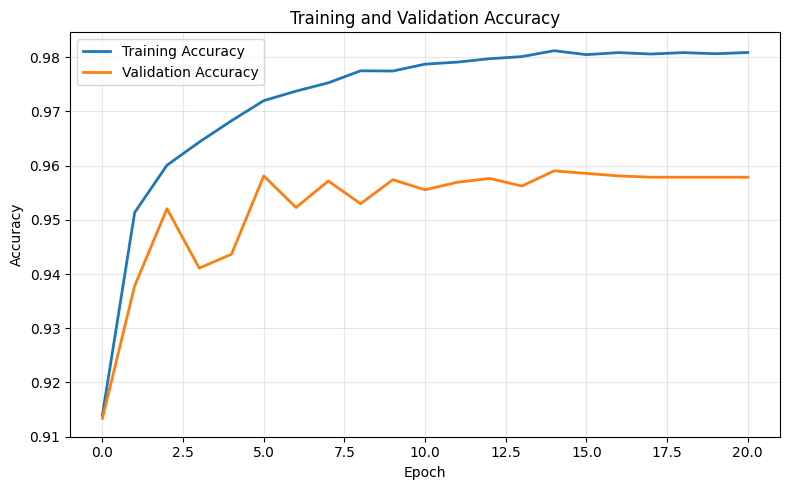

In [ ]:
# ==========================================
# BLOCK 13 : ACCURACY CURVE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

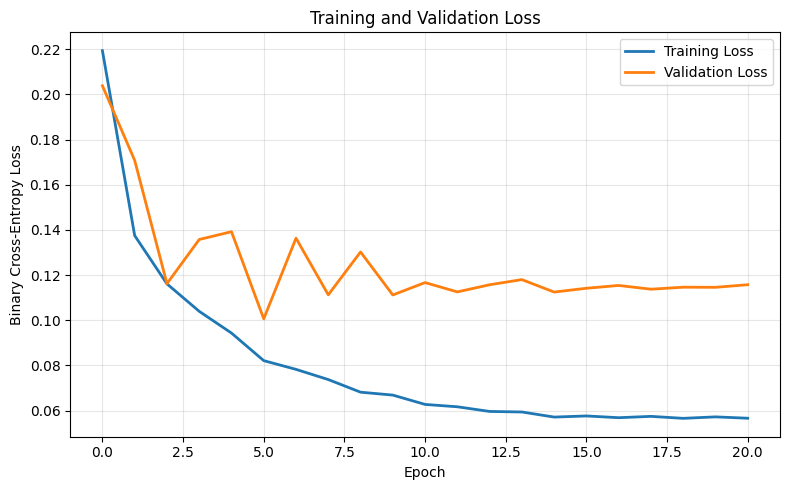

In [ ]:
# ==========================================
# BLOCK 14 : LOSS CURVE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

Confusion Matrix:
[[9650  431]
 [  58  549]]

True Negative : 9650
False Positive: 431
False Negative: 58
True Positive : 549


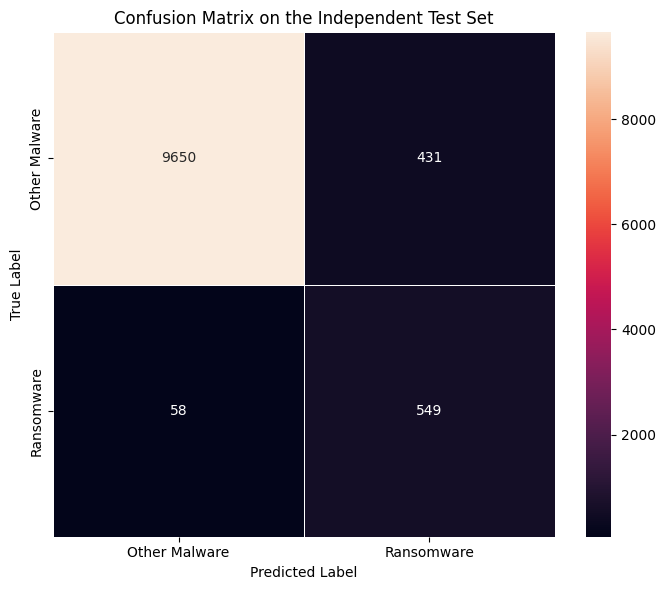

In [ ]:
# ==========================================
# BLOCK 15 : FINAL CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    linewidths=0.5,
    xticklabels=[
        "Other Malware",
        "Ransomware"
    ],
    yticklabels=[
        "Other Malware",
        "Ransomware"
    ]
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "Confusion Matrix on the Independent Test Set"
)

plt.tight_layout()

plt.show()

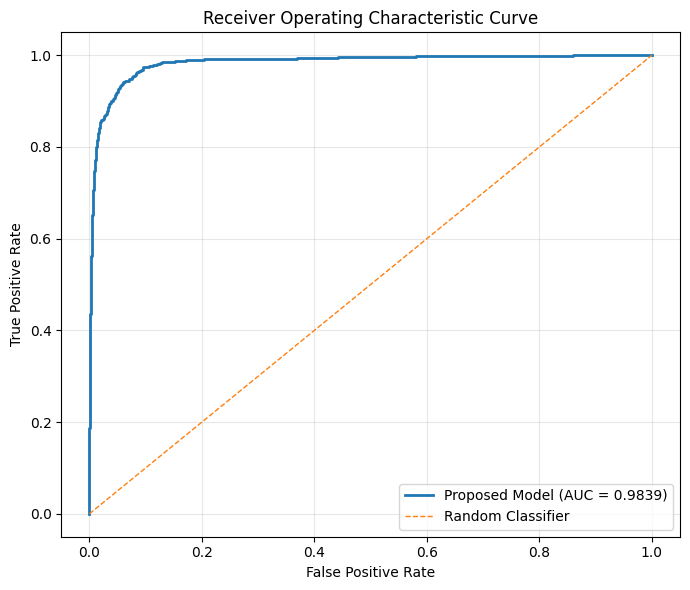

ROC-AUC: 0.9838870225310079


In [ ]:
# ==========================================
# BLOCK 16 : ROC CURVE
# ==========================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Proposed Model (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "Receiver Operating Characteristic Curve"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

print("ROC-AUC:", roc_auc)

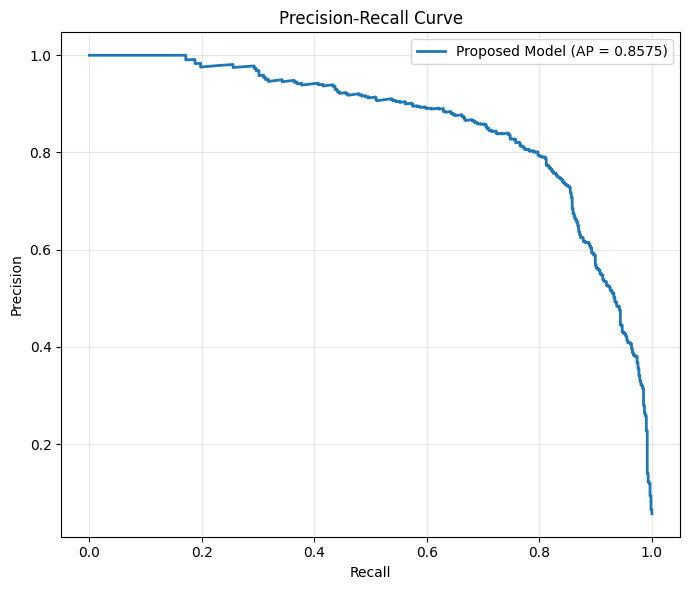

Average Precision: 0.8575205046414243


In [ ]:
# ==========================================
# BLOCK 17 : PRECISION-RECALL CURVE
# ==========================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_pred_prob
    )
)

average_precision = average_precision_score(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"Proposed Model (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

print(
    "Average Precision:",
    average_precision
)

In [ ]:
# ==========================================
# BLOCK 18 : FINAL METRICS SUMMARY
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_pred_prob),
        average_precision_score(y_test, y_pred_prob)
    ]
})

final_results["Percentage"] = (
    final_results["Score"] * 100
).round(2)

print(final_results.to_string(index=False))

           Metric    Score  Percentage
         Accuracy 0.954248       95.42
        Precision 0.560204       56.02
           Recall 0.904448       90.44
         F1-score 0.691871       69.19
          ROC-AUC 0.983887       98.39
Average Precision 0.857521       85.75


In [ ]:
# ==========================================
# BLOCK 19 : CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Other Malware",
        "Ransomware"
    ],
    digits=4,
    zero_division=0
)

print(report)

               precision    recall  f1-score   support

Other Malware     0.9940    0.9572    0.9753     10081
   Ransomware     0.5602    0.9044    0.6919       607

     accuracy                         0.9542     10688
    macro avg     0.7771    0.9308    0.8336     10688
 weighted avg     0.9694    0.9542    0.9592     10688



In [ ]:
plt.savefig(
    "confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

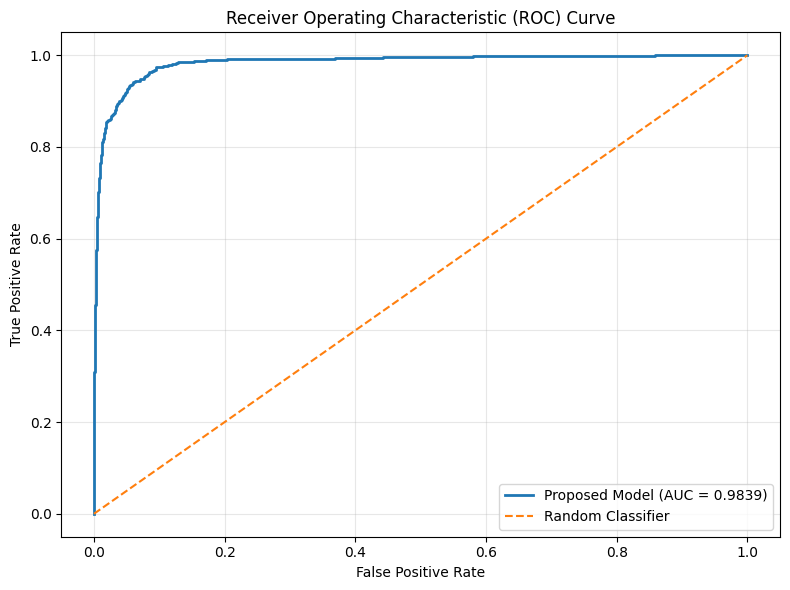

ROC-AUC: 0.9839


In [ ]:
# ==========================================
# BLOCK 16: ROC CURVE
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Proposed Model (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

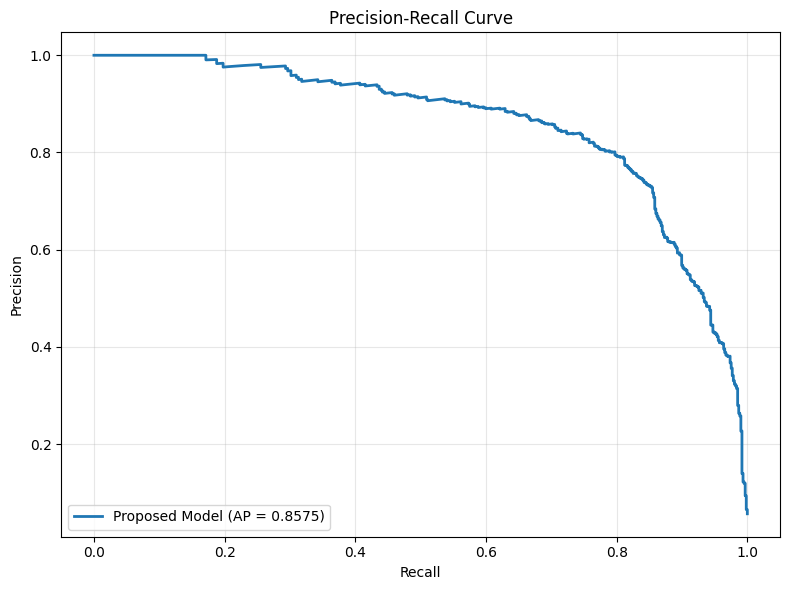

Average Precision: 0.8575


In [ ]:
# ==========================================
# BLOCK 17: PRECISION-RECALL CURVE
# ==========================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall values
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_prob
)

average_precision = average_precision_score(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"Proposed Model (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision: {average_precision:.4f}")

Preparing SHAP analysis...
Number of selected features: 120
Training SHAP background shape: (38456, 120)
Test SHAP data shape: (10688, 120)
Calculating SHAP values...


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values shape: (200, 120)


/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1920/1208225709.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


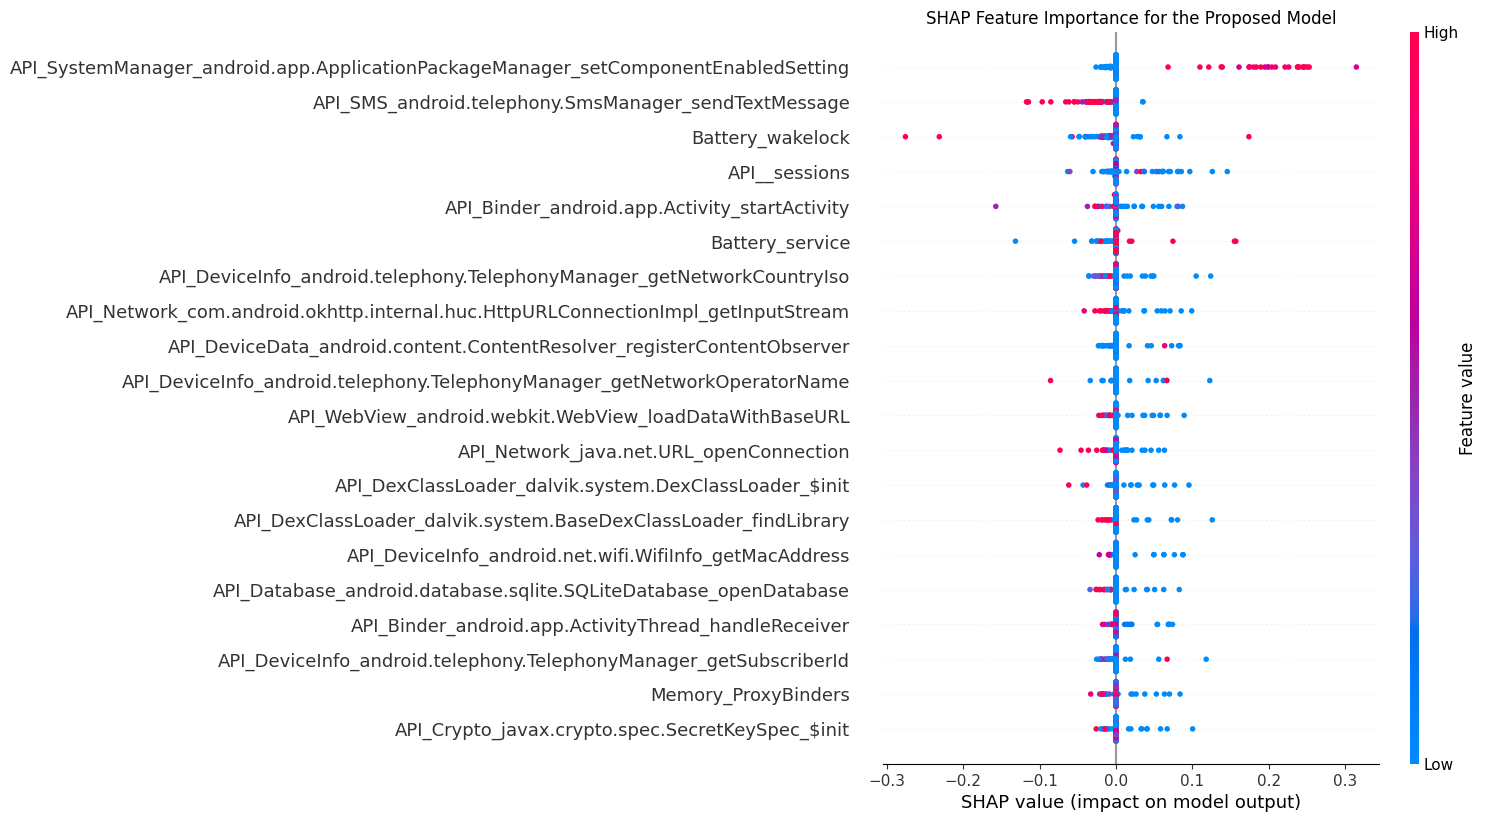

In [ ]:
# ==========================================
# BLOCK 18: SHAP USING KERNEL EXPLAINER
# ==========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Preparing SHAP analysis...")

# ------------------------------------------------
# 1. Get the names of the 120 selected features
# ------------------------------------------------

selected_mask = selector.get_support()

selected_feature_names = X.columns[selected_mask].tolist()

print("Number of selected features:", len(selected_feature_names))

# ------------------------------------------------
# 2. Create DataFrames with real feature names
# ------------------------------------------------

X_train_shap = pd.DataFrame(
    X_train_scaled,
    columns=selected_feature_names
)

X_test_shap = pd.DataFrame(
    X_test_scaled,
    columns=selected_feature_names
)

print("Training SHAP background shape:", X_train_shap.shape)
print("Test SHAP data shape:", X_test_shap.shape)

# ------------------------------------------------
# 3. Select a small training background
# ------------------------------------------------

background_size = min(100, len(X_train_shap))

background = X_train_shap.sample(
    n=background_size,
    random_state=42
)

# ------------------------------------------------
# 4. Select independent TEST samples
# ------------------------------------------------

explain_size = min(200, len(X_test_shap))

X_test_explain = X_test_shap.iloc[:explain_size].copy()

# ------------------------------------------------
# 5. Prediction function
# ------------------------------------------------

def model_predict(data):
    data_array = np.asarray(data)

    data_reshaped = data_array.reshape(
        data_array.shape[0],
        data_array.shape[1],
        1
    )

    return model.predict(
        data_reshaped,
        verbose=0
    ).flatten()

# ------------------------------------------------
# 6. KernelExplainer
# ------------------------------------------------

explainer = shap.KernelExplainer(
    model_predict,
    background
)

print("Calculating SHAP values...")

shap_values = explainer.shap_values(
    X_test_explain,
    nsamples=100
)

# ------------------------------------------------
# 7. Handle SHAP output shape
# ------------------------------------------------

if isinstance(shap_values, list):
    shap_values_plot = shap_values[0]
else:
    shap_values_plot = shap_values

shap_values_plot = np.asarray(shap_values_plot)

# Some SHAP versions may return an extra output dimension
if shap_values_plot.ndim == 3:
    shap_values_plot = shap_values_plot[:, :, 0]

print("SHAP values shape:", shap_values_plot.shape)

# ------------------------------------------------
# 8. SHAP summary plot
# ------------------------------------------------

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_plot,
    X_test_explain,
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance for the Proposed Model")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# BLOCK 19: TOP 20 SHAP FEATURES
# ==========================================

mean_abs_shap = np.mean(
    np.abs(shap_values_plot),
    axis=0
)

shap_importance = pd.DataFrame({
    "Feature": selected_feature_names,
    "Mean |SHAP Value|": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean |SHAP Value|",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 SHAP Features:")
print(
    shap_importance.head(20).to_string(index=False)
)


Top 20 SHAP Features:
                                                                           Feature  Mean |SHAP Value|
API_SystemManager_android.app.ApplicationPackageManager_setComponentEnabledSetting           0.028573
                              API_SMS_android.telephony.SmsManager_sendTextMessage           0.010027
                                                                  Battery_wakelock           0.009507
                                                                     API__sessions           0.008131
                                     API_Binder_android.app.Activity_startActivity           0.004972
                                                                   Battery_service           0.004709
            API_DeviceInfo_android.telephony.TelephonyManager_getNetworkCountryIso           0.004303
  API_Network_com.android.okhttp.internal.huc.HttpURLConnectionImpl_getInputStream           0.004078
            API_DeviceData_android.content.ContentResolver_

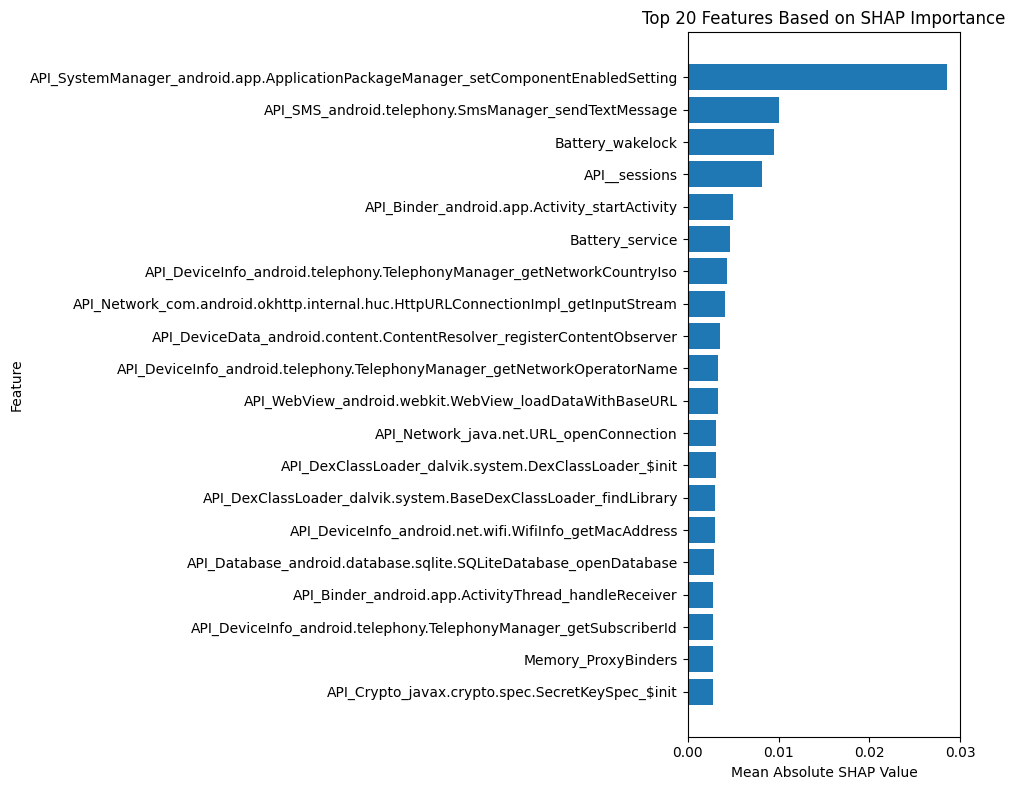

In [ ]:
# ==========================================
# BLOCK 20: TOP 20 SHAP BAR PLOT
# ==========================================

top20 = shap_importance.head(20).sort_values(
    "Mean |SHAP Value|"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Mean |SHAP Value|"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features Based on SHAP Importance")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# FINAL RESULTS TO SEND ME
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("========================================")
print("FINAL INDEPENDENT TEST RESULTS")
print("========================================")

print(f"Accuracy          : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision         : {precision_score(y_test, y_pred):.4f}")
print(f"Recall            : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score          : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Average Precision : {average_precision_score(y_test, y_pred_prob):.4f}")

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Other Malware", "Ransomware"],
        digits=4,
        zero_division=0
    )
)

print("\n========================================")
print("TEST CLASS DISTRIBUTION")
print("========================================")

print(pd.Series(y_test).value_counts().sort_index())

FINAL INDEPENDENT TEST RESULTS
Accuracy          : 0.9542
Precision         : 0.5602
Recall            : 0.9044
F1-score          : 0.6919
ROC-AUC           : 0.9839
Average Precision : 0.8575

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Other Malware     0.9940    0.9572    0.9753     10081
   Ransomware     0.5602    0.9044    0.6919       607

     accuracy                         0.9542     10688
    macro avg     0.7771    0.9308    0.8336     10688
 weighted avg     0.9694    0.9542    0.9592     10688


TEST CLASS DISTRIBUTION
Target
0    10081
1      607
Name: count, dtype: int64


In [ ]:
# ==========================================
# SMOTE VERIFICATION
# ==========================================

print("========== CLASS DISTRIBUTION ==========")

print("Original training:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nIndependent Test:")
print(y_test.value_counts().sort_index())

========== CLASS DISTRIBUTION ==========
Original training:
Target
0    35895
1     2561
Name: count, dtype: int64

After SMOTE:
Target
0    35895
1    35895
Name: count, dtype: int64

Validation:
Target
0    4052
1     243
Name: count, dtype: int64

Independent Test:
Target
0    10081
1      607
Name: count, dtype: int64


In [ ]:
print("========== HASH OVERLAP CHECK ==========")

print("Train-Test overlap:",
      len(set(groups_train).intersection(set(groups_test))))

print("Train-Validation overlap:",
      len(set(groups_train).intersection(set(groups_val))))

print("Validation-Test overlap:",
      len(set(groups_val).intersection(set(groups_test))))

========== HASH OVERLAP CHECK ==========
Train-Test overlap: 0
Train-Validation overlap: 0
Validation-Test overlap: 0


Preparing SHAP analysis...
Number of selected features: 120
Background shape: (100, 120)
Explanation data shape: (200, 120)
Calculating SHAP values...


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values shape: (200, 120)

TOP 5 SHAP FEATURES FOR IEEE PAPER
                                                              Feature Mean_Absolute_SHAP
Rank                                                                                    
1                       API_Binder_android.app.Activity_startActivity           0.011587
2                                                       API__sessions           0.005904
3     API_DexClassLoader_dalvik.system.BaseDexClassLoader_findLibrary           0.005904
4                API_FileIO_android.content.ContextWrapper_deleteFile           0.005195
5                             API_Network_java.net.URL_openConnection           0.004366


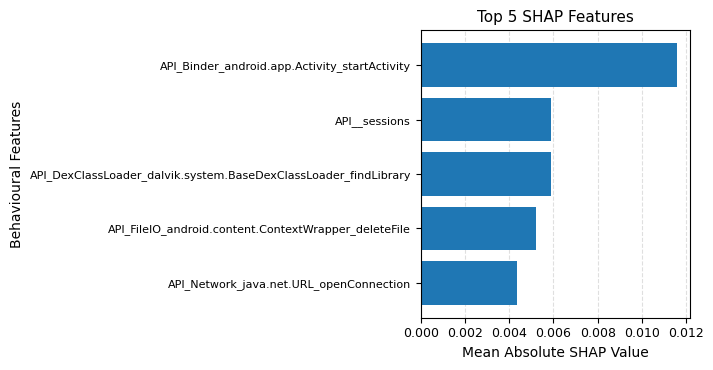


SHAP analysis completed.
Saved: SHAP_Top5_Features.csv
Saved: SHAP_All_Feature_Rankings.csv
Saved: Fig4_SHAP_Top5_IEEE.png
Saved: Fig4_SHAP_Top5_IEEE.pdf


In [ ]:

# ==========================================
# BLOCK 18: SHAP ANALYSIS AND TOP-5 FEATURES
# IEEE PAPER FIGURE
# ==========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Preparing SHAP analysis...")

# ------------------------------------------------
# 1. Recover the names of the 120 selected features
# ------------------------------------------------

selected_mask = selector.get_support()

selected_feature_names = X.columns[selected_mask].tolist()

assert len(selected_feature_names) == X_train_scaled.shape[1], \
    "Feature names do not match the scaled training data."

assert len(selected_feature_names) == X_test_scaled.shape[1], \
    "Feature names do not match the scaled test data."

print("Number of selected features:", len(selected_feature_names))

# ------------------------------------------------
# 2. Create DataFrames with the selected feature names
# ------------------------------------------------

X_train_shap = pd.DataFrame(
    np.asarray(X_train_scaled),
    columns=selected_feature_names
)

X_test_shap = pd.DataFrame(
    np.asarray(X_test_scaled),
    columns=selected_feature_names
)

# ------------------------------------------------
# 3. Select background samples from training data
# ------------------------------------------------

background_size = min(100, len(X_train_shap))

background = X_train_shap.sample(
    n=background_size,
    random_state=42
)

# ------------------------------------------------
# 4. Select representative independent test samples
# ------------------------------------------------

explain_size = min(200, len(X_test_shap))

X_test_explain = X_test_shap.sample(
    n=explain_size,
    random_state=42
)

print("Background shape:", background.shape)
print("Explanation data shape:", X_test_explain.shape)

# ------------------------------------------------
# 5. Model prediction function
# ------------------------------------------------

def model_predict(data):

    data_array = np.asarray(data, dtype=np.float32)

    data_reshaped = data_array.reshape(
        data_array.shape[0],
        data_array.shape[1],
        1
    )

    predictions = model.predict(
        data_reshaped,
        verbose=0
    )

    return predictions.reshape(-1)

# ------------------------------------------------
# 6. Create Kernel SHAP explainer
# ------------------------------------------------

explainer = shap.KernelExplainer(
    model_predict,
    background
)

print("Calculating SHAP values...")

shap_values = explainer.shap_values(
    X_test_explain,
    nsamples=100
)

# ------------------------------------------------
# 7. Handle SHAP output dimensions
# ------------------------------------------------

if isinstance(shap_values, list):
    # Binary model: select the ransomware output
    shap_values_plot = shap_values[-1]
else:
    shap_values_plot = shap_values

shap_values_plot = np.asarray(shap_values_plot)

# Handle SHAP output with an additional output dimension
if shap_values_plot.ndim == 3:

    # Expected shape: (samples, features, outputs)
    shap_values_plot = shap_values_plot[:, :, -1]

assert shap_values_plot.shape == X_test_explain.shape, \
    f"Unexpected SHAP shape: {shap_values_plot.shape}"

print("SHAP values shape:", shap_values_plot.shape)

# ------------------------------------------------
# 8. Calculate global feature importance
#    Mean absolute SHAP value across explained samples
# ------------------------------------------------

mean_abs_shap = np.mean(
    np.abs(shap_values_plot),
    axis=0
)

importance_df = pd.DataFrame({
    "Feature": selected_feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

importance_df = importance_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

importance_df.index = importance_df.index + 1
importance_df.index.name = "Rank"

# ------------------------------------------------
# 9. Print exact top 5 feature names for the paper
# ------------------------------------------------

top5_features = importance_df.head(5).copy()

print("\n======================================")
print("TOP 5 SHAP FEATURES FOR IEEE PAPER")
print("======================================")

print(
    top5_features.to_string(
        formatters={
            "Mean_Absolute_SHAP": lambda x: f"{x:.6f}"
        }
    )
)

# Save all feature rankings and top-five table
importance_df.to_csv(
    "SHAP_All_Feature_Rankings.csv"
)

top5_features.to_csv(
    "SHAP_Top5_Features.csv"
)

# ------------------------------------------------
# 10. Create IEEE-ready horizontal bar chart
# ------------------------------------------------

plot_df = top5_features.sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

fig, ax = plt.subplots(figsize=(7.2, 3.8))

ax.barh(
    plot_df["Feature"],
    plot_df["Mean_Absolute_SHAP"]
)

ax.set_xlabel(
    "Mean Absolute SHAP Value",
    fontsize=10
)

ax.set_ylabel(
    "Behavioural Features",
    fontsize=10
)

ax.set_title(
    "Top 5 SHAP Features",
    fontsize=11
)

ax.tick_params(
    axis="y",
    labelsize=8
)

ax.tick_params(
    axis="x",
    labelsize=9
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax.set_axisbelow(True)

plt.tight_layout()

# Save high-resolution figure for IEEE paper
plt.savefig(
    "Fig4_SHAP_Top5_IEEE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Fig4_SHAP_Top5_IEEE.pdf",
    bbox_inches="tight"
)

plt.show()

print("\nSHAP analysis completed.")
print("Saved: SHAP_Top5_Features.csv")
print("Saved: SHAP_All_Feature_Rankings.csv")
print("Saved: Fig4_SHAP_Top5_IEEE.png")
print("Saved: Fig4_SHAP_Top5_IEEE.pdf")

In [ ]:
# ============================================================
# ABLATION STUDY - CORRECTED DATA PIPELINE
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    GlobalAveragePooling1D,
    Dense,
    Attention
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# IMPORTANT:
# These models use the SAME corrected:
# X_train_resampled / y_train_resampled
# X_val / y_val
# X_test / y_test
# ------------------------------------------------------------

# Make sure input has correct shape
input_shape = (X_train_resampled.shape[1], 1)

print("Input shape:", input_shape)
print("Training samples:", len(X_train_resampled))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))


# ============================================================
# MODEL 1: CNN ONLY
# ============================================================

def build_cnn_only(input_shape):

    model = Sequential([
        Input(shape=input_shape),

        Conv1D(64, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        GlobalAveragePooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.30),

        Dense(64, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


# ============================================================
# MODEL 2: CNN + BiLSTM
# ============================================================

def build_cnn_bilstm(input_shape):

    model = Sequential([
        Input(shape=input_shape),

        Conv1D(64, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Bidirectional(
            LSTM(128, return_sequences=True)
        ),

        GlobalAveragePooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.30),

        Dense(64, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


# ============================================================
# TRAIN + EVALUATE FUNCTION
# ============================================================

def train_and_evaluate(model, model_name, epochs=25):

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    history = model.fit(
        X_train_resampled,
        y_train_resampled,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=128,
        verbose=1
    )

    # --------------------------------------------------------
    # Independent test prediction
    # --------------------------------------------------------

    y_prob = model.predict(
        X_test,
        verbose=0
    ).flatten()

    y_pred_model = (y_prob >= 0.5).astype(int)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(
            y_test,
            y_pred_model,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_model,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            y_pred_model,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "Average Precision": average_precision_score(
            y_test,
            y_prob
        )
    }

    print("\n" + "-" * 60)
    print("TEST RESULTS:", model_name)
    print("-" * 60)

    for metric, value in results.items():

        if metric != "Model":
            print(f"{metric:20s}: {value:.4f}")

    return model, history, results


# ============================================================
# RUN CNN ONLY
# ============================================================

cnn_model = build_cnn_only(input_shape)

cnn_model, cnn_history, cnn_results = train_and_evaluate(
    cnn_model,
    "CNN Only",
    epochs=25
)


# ============================================================
# RUN CNN + BiLSTM
# ============================================================

cnn_bilstm_model = build_cnn_bilstm(input_shape)

cnn_bilstm_model, cnn_bilstm_history, cnn_bilstm_results = train_and_evaluate(
    cnn_bilstm_model,
    "CNN + BiLSTM",
    epochs=25
)


# ============================================================
# COMBINE ABLATION RESULTS
# ============================================================

# Proposed model results from your corrected experiment
proposed_results = {
    "Model": "CNN + BiLSTM + Attention",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "F1-score": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_pred_prob
    ),
    "Average Precision": average_precision_score(
        y_test,
        y_pred_prob
    )
}


ablation_results = pd.DataFrame([
    cnn_results,
    cnn_bilstm_results,
    proposed_results
])

print("\n")
print("=" * 80)
print("FINAL ABLATION STUDY")
print("=" * 80)

print(
    ablation_results.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1-score": "{:.4f}".format,
            "ROC-AUC": "{:.4f}".format,
            "Average Precision": "{:.4f}".format
        }
    )
)

Input shape: (120, 1)
Training samples: 71790
Validation samples: 4295
Test samples: 10688

CNN Only
Epoch 1/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8677 - loss: 0.3183 - precision: 0.8582 - recall: 0.8810 - val_accuracy: 0.5497 - val_loss: 0.8426 - val_precision: 0.1109 - val_recall: 0.9918
Epoch 2/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9080 - loss: 0.2321 - precision: 0.9058 - recall: 0.9106 - val_accuracy: 0.9299 - val_loss: 0.1862 - val_precision: 0.4398 - val_recall: 0.8724
Epoch 3/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9200 - loss: 0.2048 - precision: 0.9146 - recall: 0.9265 - val_accuracy: 0.8675 - val_loss: 0.2987 - val_precision: 0.2926 - val_recall: 0.9465
Epoch 4/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9273 - loss: 0.1881 - precision: 0.9199 - recall: 0.9361 - val_accuracy: 0.9374 - val_loss: 0.1594 - val_precision: 0.4721 - val_recall: 0.9053
Epoch 5/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc

In [ ]:
# ==========================================
# THRESHOLD ANALYSIS FOR PROPOSED MODEL
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    pred = (y_pred_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))

print("\nBest threshold by F1:")
print(
    threshold_df.loc[
        threshold_df["F1-score"].idxmax()
    ]
)

 Threshold  Accuracy  Precision   Recall  F1-score
      0.10  0.922156   0.418773 0.955519  0.582329
      0.15  0.934600   0.462843 0.943987  0.621138
      0.20  0.942833   0.498243 0.934102  0.649857
      0.25  0.945453   0.510850 0.930807  0.659661
      0.30  0.948166   0.524790 0.924217  0.669451
      0.35  0.949850   0.533971 0.919275  0.675545
      0.40  0.951534   0.543670 0.912685  0.681427
      0.45  0.952938   0.552104 0.907743  0.686604
      0.50  0.954248   0.560204 0.904448  0.691871
      0.55  0.955371   0.567568 0.899506  0.695985
      0.60  0.958084   0.585209 0.899506  0.709091
      0.65  0.959487   0.595604 0.892916  0.714568
      0.70  0.961920   0.614679 0.883031  0.724814
      0.75  0.966598   0.655860 0.866557  0.746629
      0.80  0.973709   0.730878 0.850082  0.785986
      0.85  0.975954   0.772586 0.817133  0.794235
      0.90  0.976609   0.806175 0.774300  0.789916

Best threshold by F1:
Threshold    0.850000
Accuracy     0.975954
Precision    0.

In [ ]:
# ============================================================
# VALIDATION-BASED THRESHOLD SELECTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Get probabilities for VALIDATION set
# ------------------------------------------------------------

val_prob = model.predict(
    X_val,
    verbose=0
).flatten()

# ------------------------------------------------------------
# 2. Evaluate thresholds ONLY on validation set
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.01)

validation_results = []

for threshold in thresholds:

    val_pred = (val_prob >= threshold).astype(int)

    validation_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_val,
            val_pred,
            zero_division=0
        )
    })

validation_df = pd.DataFrame(validation_results)

# ------------------------------------------------------------
# 3. Select threshold based on VALIDATION F1
# ------------------------------------------------------------

best_row = validation_df.loc[
    validation_df["F1-score"].idxmax()
]

best_threshold = float(best_row["Threshold"])

print("========================================")
print("BEST VALIDATION THRESHOLD")
print("========================================")

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1-score  : {best_row['F1-score']:.4f}")


# ============================================================
# 4. APPLY THE FROZEN THRESHOLD TO TEST SET
# ============================================================

test_pred_threshold = (
    y_pred_prob >= best_threshold
).astype(int)

print("\n========================================")
print("INDEPENDENT TEST RESULTS")
print(f"Threshold = {best_threshold:.2f}")
print("========================================")

print(
    f"Accuracy  : "
    f"{accuracy_score(y_test, test_pred_threshold):.4f}"
)

print(
    f"Precision : "
    f"{precision_score(y_test, test_pred_threshold, zero_division=0):.4f}"
)

print(
    f"Recall    : "
    f"{recall_score(y_test, test_pred_threshold, zero_division=0):.4f}"
)

print(
    f"F1-score  : "
    f"{f1_score(y_test, test_pred_threshold, zero_division=0):.4f}"
)

BEST VALIDATION THRESHOLD
Threshold : 0.86
Accuracy  : 0.9779
Precision : 0.8008
Recall    : 0.8107
F1-score  : 0.8057

INDEPENDENT TEST RESULTS
Threshold = 0.86
Accuracy  : 0.9761
Precision : 0.7776
Recall    : 0.8122
F1-score  : 0.7945


In [ ]:
# ============================================================
# VALIDATION-BASED THRESHOLD FOR CNN / CNN-BiLSTM
# ============================================================

def evaluate_model_with_validation_threshold(
    trained_model,
    model_name
):

    # Validation probabilities
    val_prob = trained_model.predict(
        X_val,
        verbose=0
    ).flatten()

    # Test probabilities
    test_prob = trained_model.predict(
        X_test,
        verbose=0
    ).flatten()

    thresholds = np.arange(0.10, 0.91, 0.01)

    validation_scores = []

    for threshold in thresholds:

        val_pred = (
            val_prob >= threshold
        ).astype(int)

        validation_scores.append({
            "Threshold": threshold,
            "F1": f1_score(
                y_val,
                val_pred,
                zero_division=0
            )
        })

    validation_scores = pd.DataFrame(
        validation_scores
    )

    best_threshold = float(
        validation_scores.loc[
            validation_scores["F1"].idxmax(),
            "Threshold"
        ]
    )

    # Apply frozen threshold to TEST
    test_pred = (
        test_prob >= best_threshold
    ).astype(int)

    results = {
        "Model": model_name,
        "Threshold": best_threshold,
        "Accuracy": accuracy_score(
            y_test,
            test_pred
        ),
        "Precision": precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            test_prob
        ),
        "Average Precision": average_precision_score(
            y_test,
            test_prob
        )
    }

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    for key, value in results.items():

        if key == "Model":
            continue

        print(f"{key:20s}: {value:.4f}")

    return results

In [ ]:
cnn_threshold_results = evaluate_model_with_validation_threshold(
    cnn_model,
    "CNN Only"
)

cnn_bilstm_threshold_results = evaluate_model_with_validation_threshold(
    cnn_bilstm_model,
    "CNN + BiLSTM"
)


CNN Only
Threshold           : 0.9000
Accuracy            : 0.9655
Precision           : 0.6514
Recall              : 0.8435
F1-score            : 0.7351
ROC-AUC             : 0.9802
Average Precision   : 0.8452

CNN + BiLSTM
Threshold           : 0.9000
Accuracy            : 0.9762
Precision           : 0.7788
Recall              : 0.8122
F1-score            : 0.7952
ROC-AUC             : 0.9836
Average Precision   : 0.8650


In [ ]:
# ============================================================
# FINAL PROPOSED MODEL EVALUATION
# VALIDATION-SELECTED THRESHOLD = 0.89
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# ------------------------------------------------------------
# FIXED THRESHOLD SELECTED FROM VALIDATION SET
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.89

# ------------------------------------------------------------
# INDEPENDENT TEST PREDICTIONS
# ------------------------------------------------------------

y_pred_prob = model.predict(
    X_test,
    verbose=0
).flatten()

# Apply validation-selected threshold
y_pred_final = (
    y_pred_prob >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred_final
)

precision = precision_score(
    y_test,
    y_pred_final,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_final,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_final,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob
)

average_precision = average_precision_score(
    y_test,
    y_pred_prob
)

# ------------------------------------------------------------
# PRINT FINAL RESULTS
# ------------------------------------------------------------

print("=" * 60)
print("FINAL PROPOSED MODEL")
print("=" * 60)

print(f"Classification Threshold : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy                 : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision                : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall                   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score                 : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC                  : {roc_auc:.4f}")
print(f"Average Precision        : {average_precision:.4f}")

FINAL PROPOSED MODEL
Classification Threshold : 0.89
Accuracy                 : 0.9770 (97.70%)
Precision                : 0.8013 (80.13%)
Recall                   : 0.7908 (79.08%)
F1-score                 : 0.7960 (79.60%)
ROC-AUC                  : 0.9839
Average Precision        : 0.8575


CONFUSION MATRIX
[[9962  119]
 [ 127  480]]

True Negative  (TN): 9962
False Positive (FP): 119
False Negative (FN): 127
True Positive  (TP): 480


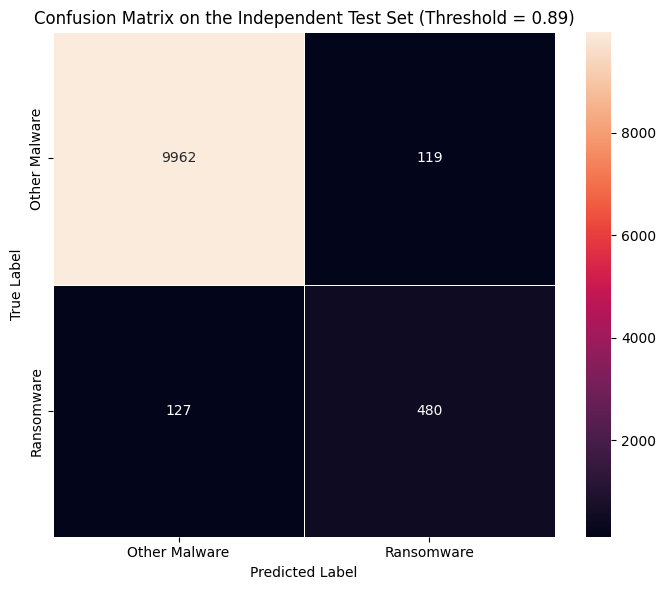

In [ ]:
# ============================================================
# FINAL CONFUSION MATRIX - THRESHOLD 0.89
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_final
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive  (TP): {tp}")

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    linewidths=0.5,
    xticklabels=["Other Malware", "Ransomware"],
    yticklabels=["Other Malware", "Ransomware"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "Confusion Matrix on the Independent Test Set "
    "(Threshold = 0.89)"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CLASSIFICATION REPORT - THRESHOLD 0.89
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "Other Malware",
            "Ransomware"
        ],
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Other Malware     0.9874    0.9882    0.9878     10081
   Ransomware     0.8013    0.7908    0.7960       607

     accuracy                         0.9770     10688
    macro avg     0.8944    0.8895    0.8919     10688
 weighted avg     0.9768    0.9770    0.9769     10688



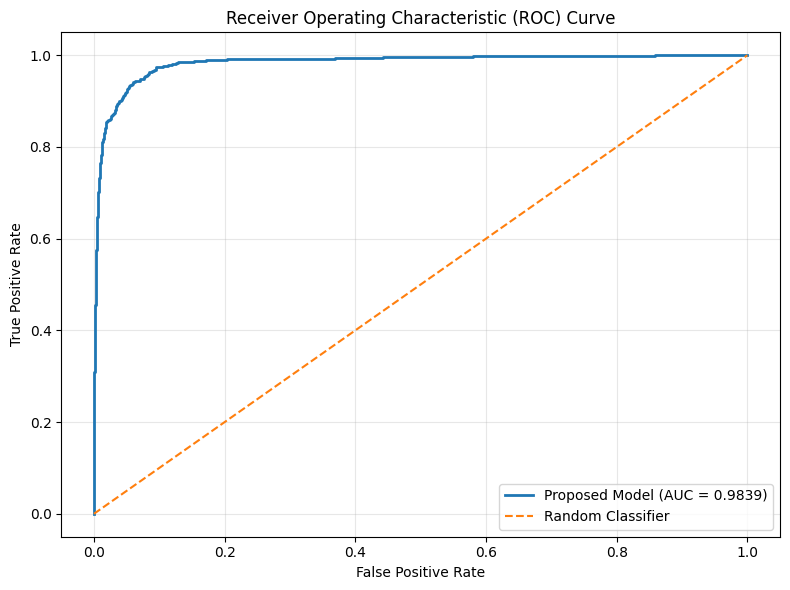

In [ ]:
# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Proposed Model (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

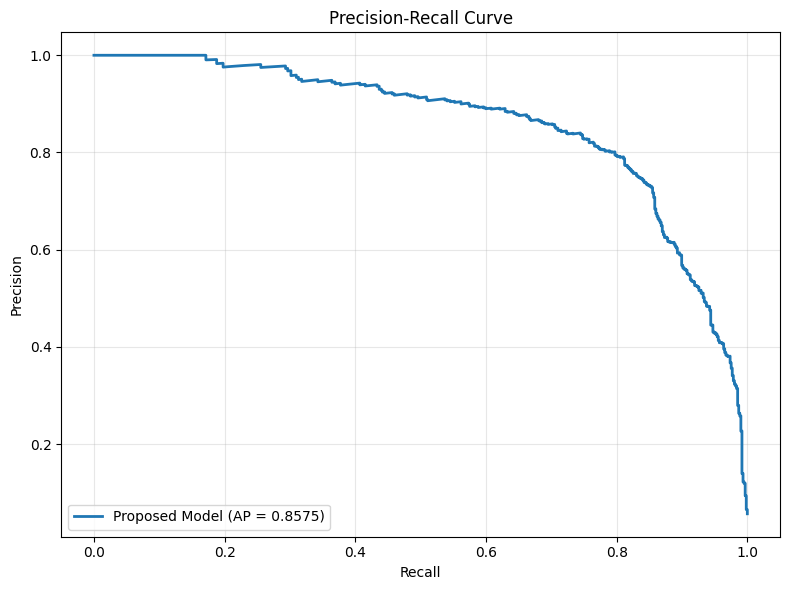

In [ ]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"Proposed Model (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})

final_results["Percentage"] = (
    final_results["Score"] * 100
).round(2)

print(final_results.to_string(index=False))

           Metric    Score  Percentage
         Accuracy 0.976984       97.70
        Precision 0.801336       80.13
           Recall 0.790774       79.08
         F1-score 0.796020       79.60
          ROC-AUC 0.983887       98.39
Average Precision 0.857521       85.75


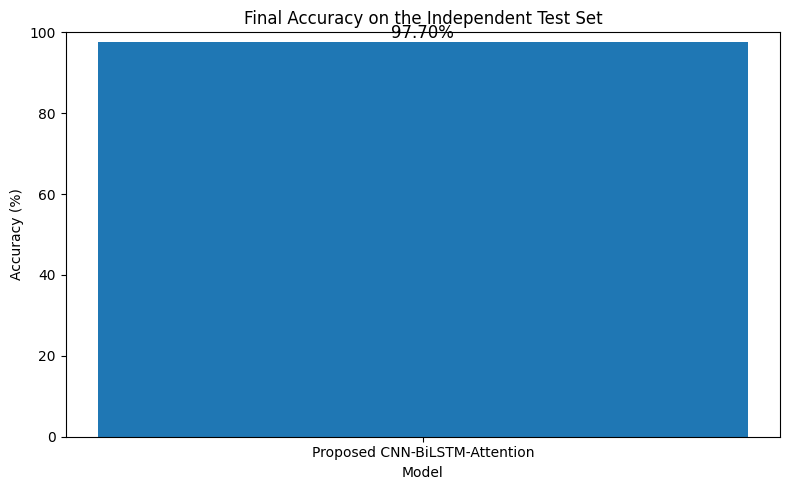

In [ ]:
# ============================================================
# FINAL MODEL ACCURACY GRAPH
# ============================================================

import matplotlib.pyplot as plt

# Final independent-test accuracy
final_accuracy = accuracy * 100

plt.figure(figsize=(8, 5))

plt.bar(
    ["Proposed CNN-BiLSTM-Attention"],
    [final_accuracy]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Final Accuracy on the Independent Test Set")

plt.ylim(0, 100)

# Display exact value above bar
plt.text(
    0,
    final_accuracy + 1,
    f"{final_accuracy:.2f}%",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PROPOSED CNN-BiLSTM-ATTENTION MODEL
# FUNCTIONAL API VERSION
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Attention,
    GlobalAveragePooling1D,
    Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Input shape
# ------------------------------------------------------------

input_shape = (
    X_train_resampled.shape[1],
    1
)

print("Input shape:", input_shape)
print("Training samples:", X_train_resampled.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])


# ============================================================
# INPUT
# ============================================================

inputs = Input(
    shape=input_shape,
    name="Input"
)


# ============================================================
# CNN BLOCK 1
# ============================================================

x = Conv1D(
    64,
    kernel_size=3,
    activation="relu",
    name="Conv1D_64"
)(inputs)

x = BatchNormalization(
    name="BatchNorm_1"
)(x)

x = MaxPooling1D(
    pool_size=2,
    name="MaxPool_1"
)(x)

x = Dropout(
    0.25,
    name="Dropout_1"
)(x)


# ============================================================
# CNN BLOCK 2
# ============================================================

x = Conv1D(
    128,
    kernel_size=3,
    activation="relu",
    name="Conv1D_128"
)(x)

x = BatchNormalization(
    name="BatchNorm_2"
)(x)

x = MaxPooling1D(
    pool_size=2,
    name="MaxPool_2"
)(x)

x = Dropout(
    0.25,
    name="Dropout_2"
)(x)


# ============================================================
# BiLSTM
# ============================================================

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    ),
    name="BiLSTM"
)(x)


# ============================================================
# SELF-ATTENTION
# ============================================================

attention_output = Attention(
    name="Self_Attention"
)([x, x])


# ============================================================
# GLOBAL AVERAGE POOLING
# ============================================================

x = GlobalAveragePooling1D(
    name="GlobalAveragePooling"
)(attention_output)


# ============================================================
# DENSE CLASSIFICATION HEAD
# ============================================================

x = Dense(
    128,
    activation="relu",
    name="Dense_128"
)(x)

x = Dropout(
    0.30,
    name="Dropout_3"
)(x)

x = Dense(
    64,
    activation="relu",
    name="Dense_64"
)(x)

outputs = Dense(
    1,
    activation="sigmoid",
    name="Output"
)(x)


# ============================================================
# CREATE MODEL
# ============================================================

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="CNN_BiLSTM_Attention"
)


# ============================================================
# COMPILE
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Input shape: (120, 1)
Training samples: 71790
Validation samples: 4295
Test samples: 10688


Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 120, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_64 (Conv1D)  │ (None, 118, 64)   │        256 │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNorm_1         │ (None, 118, 64)   │        256 │ Conv1D_64[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_1           │ (None, 59, 64)    │          0 │ BatchNorm_1[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_1 (Dropout) │ (None, 59, 64)    │          0 │ MaxPool_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_128 (Conv1D) │ (None, 57, 128)   │     24,704 │ Dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNorm_2         │ (None, 57, 128)   │        512 │ Conv1D_128[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_2           │ (None, 28, 128)   │          0 │ BatchNorm_2[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_2 (Dropout) │ (None, 28, 128)   │          0 │ MaxPool_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM              │ (None, 28, 256)   │    263,168 │ Dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Self_Attention      │ (None, 28, 256)   │          0 │ BiLSTM[0][0],     │
│ (Attention)         │                   │            │ BiLSTM[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalAveragePooli… │ (None, 256)       │          0 │ Self_Attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_128 (Dense)   │ (None, 128)       │     32,896 │ GlobalAveragePoo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_3 (Dropout) │ (None, 128)       │          0 │ Dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_64 (Dense)    │ (None, 64)        │      8,256 │ Dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 1)         │         65 │ Dense_64[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 330,113 (1.26 MB)

 Trainable params: 329,729 (1.26 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ============================================================
# TRAIN PROPOSED MODEL
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train_resampled,
    y_train_resampled,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=25,
    batch_size=128,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9026 - loss: 0.2413 - precision: 0.8916 - recall: 0.9165 - val_accuracy: 0.8957 - val_loss: 0.2581 - val_precision: 0.3333 - val_recall: 0.8436 - learning_rate: 0.0010
Epoch 2/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9470 - loss: 0.1450 - precision: 0.9353 - recall: 0.9604 - val_accuracy: 0.9369 - val_loss: 0.1672 - val_precision: 0.4714 - val_recall: 0.9506 - learning_rate: 0.0010
Epoch 3/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9571 - loss: 0.1230 - precision: 0.9451 - recall: 0.9706 - val_accuracy: 0.9425 - val_loss: 0.1521 - val_precision: 0.4957 - val_recall: 0.9465 - learning_rate: 0.0010
Epoch 4/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9632 - loss: 0.1073 - precision: 0.9506 - recall: 0.9772 - val_accuracy: 0.9460 - val_loss: 0.1298 - val_precision: 0.5122 - val_recall: 0.9465 - learning_rate: 0.0010
Epoch 5/25
561/561 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accu

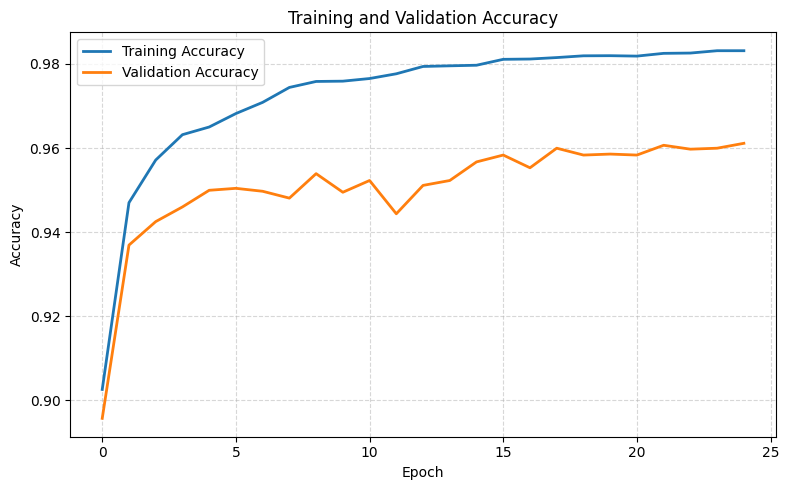

In [ ]:
# ============================================================
# GRAPH 1: TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

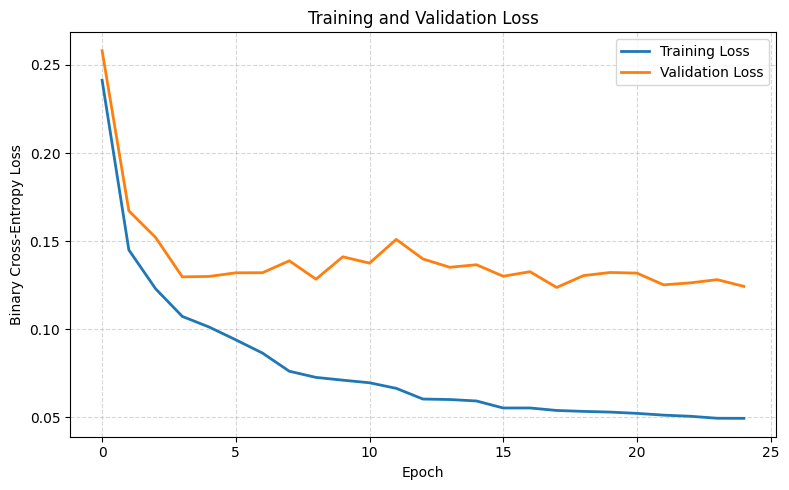

In [ ]:
# ============================================================
# GRAPH 2: TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


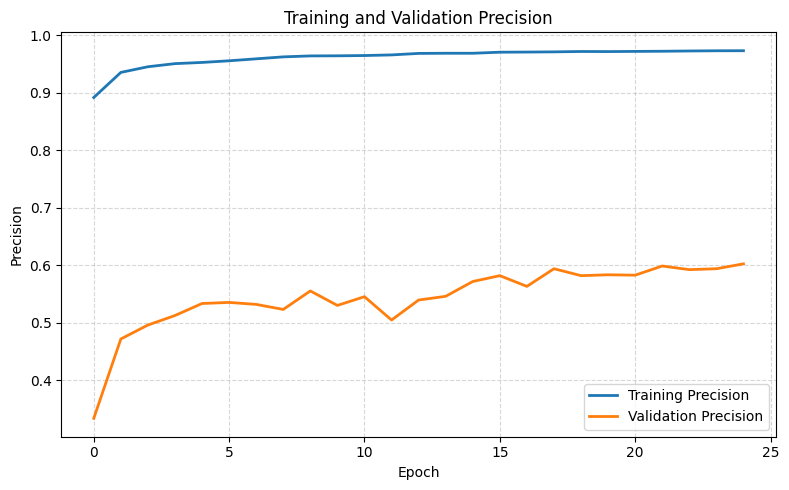

In [ ]:
# ============================================================
# GRAPH 3: TRAINING AND VALIDATION PRECISION
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["precision"],
    label="Training Precision",
    linewidth=2
)

plt.plot(
    history.history["val_precision"],
    label="Validation Precision",
    linewidth=2
)

plt.title("Training and Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

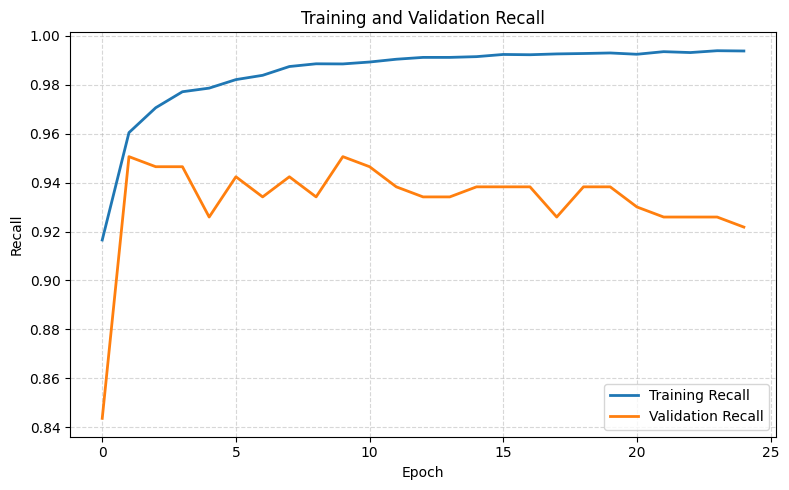

In [ ]:
# ============================================================
# GRAPH 4: TRAINING AND VALIDATION RECALL
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["recall"],
    label="Training Recall",
    linewidth=2
)

plt.plot(
    history.history["val_recall"],
    label="Validation Recall",
    linewidth=2
)

plt.title("Training and Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SELECT OPTIMAL THRESHOLD USING VALIDATION DATA
# ============================================================

import numpy as np
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Predict probabilities on validation set
y_val_prob = model.predict(X_val).ravel()

# Convert labels to 1D array
y_val_true = np.asarray(y_val).ravel().astype(int)

# Search for threshold that maximizes validation F1
thresholds = np.arange(0.01, 1.00, 0.01)

best_threshold = 0.5
best_f1 = -1

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    current_f1 = f1_score(
        y_val_true,
        y_val_pred,
        zero_division=0
    )

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print("Best validation threshold:", best_threshold)
print("Best validation F1-score:", best_f1)

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Best validation threshold: 0.9500000000000001
Best validation F1-score: 0.7852494577006508


In [ ]:
# ============================================================
# CONFUSION MATRIX ON INDEPENDENT TEST SET
# ============================================================

# Predict test probabilities
y_test_prob = model.predict(X_test).ravel()

# Actual test labels
y_test_true = np.asarray(y_test).ravel().astype(int)

# Apply the frozen validation threshold
y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

# Compute confusion matrix
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

# Compute final test metrics
accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

precision = precision_score(
    y_test_true,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test_true,
    y_test_pred,
    zero_division=0
)

print("\nIndependent Test Results")
print("------------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion Matrix:
[[9961  120]
 [ 136  471]]

True Negative (TN): 9961
False Positive (FP): 120
False Negative (FN): 136
True Positive (TP): 471

Independent Test Results
------------------------
Accuracy : 97.60%
Precision: 79.70%
Recall   : 77.59%


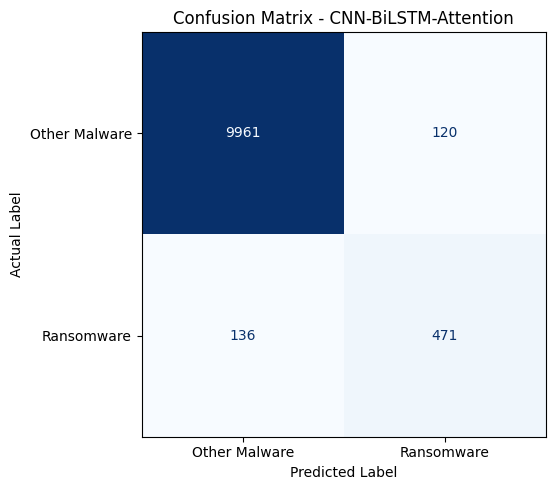

In [ ]:
# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Other Malware",
        "Ransomware"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix - CNN-BiLSTM-Attention"
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "CNN_BiLSTM_Attention_Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

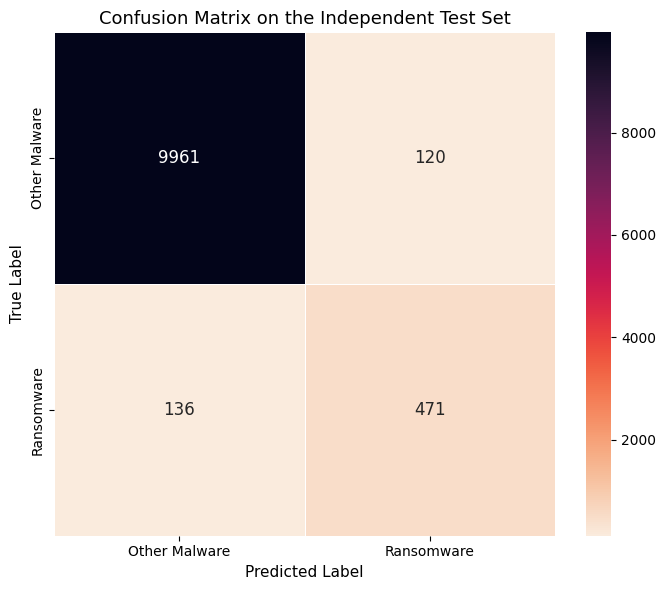

In [ ]:
# ============================================================
# CONFUSION MATRIX - REFERENCE IMAGE STYLE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix using final test predictions
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=[0, 1]
)

# Plot
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="rocket_r",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Other Malware", "Ransomware"],
    yticklabels=["Other Malware", "Ransomware"],
    annot_kws={"size": 12}
)

plt.title(
    "Confusion Matrix on the Independent Test Set",
    fontsize=13
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

plt.xticks(rotation=0)
plt.yticks(rotation=90)

plt.tight_layout()

# Save high-resolution image for IEEE paper
plt.savefig(
    "Confusion_Matrix_IEEE.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install shap

In [ ]:
# ============================================================
# SHAP ANALYSIS - CNN-BiLSTM-ATTENTION
# TOP 5 BEHAVIOURAL FEATURES
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare input data
# ------------------------------------------------------------

n_features = X_test.shape[1]

# Flatten the CNN input for SHAP
X_background = X_train_resampled.reshape(
    X_train_resampled.shape[0], n_features
)

X_test_flat = X_test.reshape(
    X_test.shape[0], n_features
)

# Use representative samples to reduce computation time
np.random.seed(42)

background_idx = np.random.choice(
    len(X_background),
    size=min(50, len(X_background)),
    replace=False
)

test_idx = np.random.choice(
    len(X_test_flat),
    size=min(200, len(X_test_flat)),
    replace=False
)

background = X_background[background_idx]
X_explain = X_test_flat[test_idx]

# ------------------------------------------------------------
# 2. Define prediction function
# ------------------------------------------------------------

def predict_for_shap(X):
    X = np.asarray(X).reshape(
        -1, n_features, 1
    )

    return model.predict(
        X,
        verbose=0
    ).reshape(-1)

# ------------------------------------------------------------
# 3. Create SHAP explainer
# ------------------------------------------------------------

explainer = shap.KernelExplainer(
    predict_for_shap,
    background
)

# Calculate SHAP values
shap_values = explainer.shap_values(
    X_explain,
    nsamples=100
)

# Handle SHAP output dimensions
shap_values = np.asarray(shap_values)

if shap_values.ndim == 3:
    shap_values = shap_values[..., 0]

print("SHAP values shape:", shap_values.shape)

  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=3.046e-02, with an active set of 1 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


SHAP values shape: (200, 120)


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# RANK FEATURES BY MEAN ABSOLUTE SHAP VALUE
# ============================================================

# IMPORTANT:
# Use the actual selected feature names from your
# preprocessing pipeline, in the same column order as X_test.

# Example:
# selected_feature_names = selected_columns

# If you have not retained the names, use the actual
# input column names from your original dataframe.
# Do not use arbitrary feature names in the paper.


# Verify dimensions
assert len(selected_feature_names) == n_features

# Calculate mean absolute SHAP value
mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

# Create ranking table
shap_importance = pd.DataFrame({
    "Feature": selected_feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Top 5 features
top5_shap = shap_importance.head(5)

print("\nTOP 5 BEHAVIOURAL FEATURES")
print(top5_shap.to_string(index=False))

# Save complete ranking
shap_importance.to_csv(
    "SHAP_Feature_Ranking.csv",
    index=False
)


TOP 5 BEHAVIOURAL FEATURES
                                                           Feature  Mean_Absolute_SHAP
API_SystemManager_android.content.BroadcastReceiver_abortBroadcast            0.021185
                                                     API__sessions            0.021025
                     API_Binder_android.app.Activity_startActivity            0.015572
               API_Binder_android.app.ContextImpl_registerReceiver            0.014276
                                                  Battery_wakelock            0.014030


In [ ]:
selected_feature_names = selected_feature_names

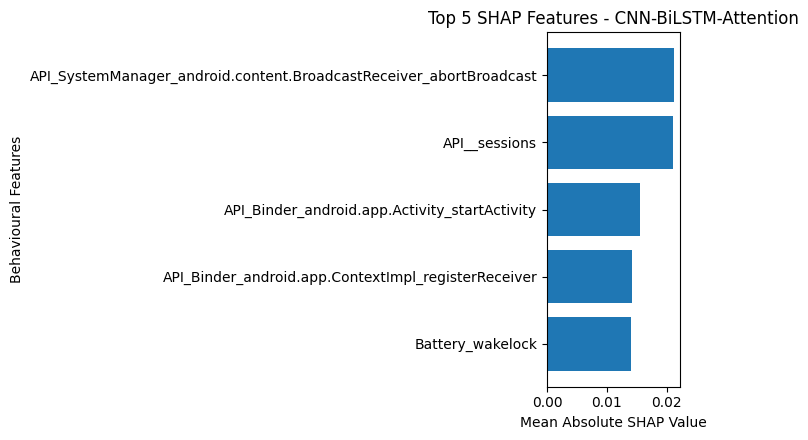

In [ ]:
# ============================================================
# FIG. 4 - TOP 5 SHAP FEATURE IMPORTANCE
# ============================================================

top5_plot = top5_shap.sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

plt.figure(figsize=(7, 4.5))

plt.barh(
    top5_plot["Feature"],
    top5_plot["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Behavioural Features")

plt.title(
    "Top 5 SHAP Features - CNN-BiLSTM-Attention"
)

plt.tight_layout()

plt.savefig(
    "SHAP_Top5_IEEE.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()